# Protein Correlation Network Pipeline

This notebook applies the same protein filtering logic used in the clustering workflow, computes protein–protein correlations across drugs, extracts edges above a chosen threshold, and visualizes the resulting correlation network.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## 2. Protein filtering function

This function applies the same filtering logic as your protein clustering workflow:

- non-missing fraction >= 0.7
- standard deviation across drugs >= 0.2
- maximum absolute value across drugs >= 0.5

It also performs optional missing-value imputation.


In [2]:
def filter_proteins_for_corr(
    protein_drug_matrix,
    gene_symbol_col="gene_symbol",
    min_non_na_frac=0.7,
    min_std=0.2,
    min_max_abs=0.5,
    fillna_method="row_mean"
):
    df = protein_drug_matrix.copy()
    df.index = df.index.astype(str)

    # separate metadata and numeric matrix
    if gene_symbol_col in df.columns:
        gene_symbol = df[gene_symbol_col].copy()
        drug_df = df.drop(columns=[gene_symbol_col]).copy()
    else:
        gene_symbol = pd.Series(index=df.index, data=np.nan, name="gene_symbol")
        drug_df = df.copy()

    # numeric conversion
    drug_df = drug_df.replace([np.inf, -np.inf], np.nan)
    drug_df = drug_df.apply(pd.to_numeric, errors="coerce")
    drug_df = drug_df.dropna(how="all", axis=0)

    # align metadata
    gene_symbol = gene_symbol.loc[drug_df.index]

    # filtering logic
    non_na_frac = drug_df.notna().mean(axis=1)
    row_std = drug_df.std(axis=1, skipna=True)
    row_max_abs = drug_df.abs().max(axis=1, skipna=True)

    keep_mask = (
        (non_na_frac >= min_non_na_frac) &
        (row_std >= min_std) &
        (row_max_abs >= min_max_abs)
    )

    df_filt = drug_df.loc[keep_mask].copy()
    gene_symbol_filt = gene_symbol.loc[df_filt.index].copy()

    # fill missing values
    if fillna_method == "row_mean":
        means = df_filt.mean(axis=1)
        df_filled = df_filt.T.fillna(means).T
    elif fillna_method == "zero":
        df_filled = df_filt.fillna(0)
    else:
        raise ValueError("fillna_method must be 'row_mean' or 'zero'")

    return df_filt, df_filled, gene_symbol_filt

## 3. Compute protein–protein correlation matrix

In [3]:
def compute_protein_corr(df_filled, method="pearson"):
    # rows = proteins, columns = drugs
    # transpose so that corr() returns protein-protein correlation
    corr_df = df_filled.T.corr(method=method)
    return corr_df

## 4. Convert correlation matrix to edge table

This keeps only the upper triangle of the matrix to avoid duplicate edges.
You can retain only positive correlations above a threshold, or use absolute correlation.


In [40]:
def corr_to_edge_table(corr_df, corr_thresh=0.5, use_abs=False):
    corr_df = corr_df.copy()

    # 去掉 index / columns 中包含 cRAP- 的蛋白
    keep_rows = ~corr_df.index.astype(str).str.contains("cRAP-", na=False)
    keep_cols = ~corr_df.columns.astype(str).str.contains("cRAP-", na=False)
    corr_df = corr_df.loc[keep_rows, keep_cols]

    # 避免 index name / columns name 重名导致 reset_index 报错
    corr_df.index.name = None
    corr_df.columns.name = None

    # 只保留上三角，避免重复
    mask = np.triu(np.ones(corr_df.shape), k=1).astype(bool)
    upper_df = corr_df.where(mask)

    edges_df = upper_df.stack().reset_index()
    edges_df.columns = ["protein1", "protein2", "correlation"]

    if use_abs:
        edges_df = edges_df.loc[edges_df["correlation"].abs() > corr_thresh].copy()
    else:
        edges_df = edges_df.loc[edges_df["correlation"] > corr_thresh].copy()

    edges_df = edges_df.sort_values("correlation", ascending=False).reset_index(drop=True)
    return edges_df

## 5. Plot the protein correlation network

- node labels use `gene_symbol` when available
- node size is scaled by degree
- edge width is scaled by correlation strength


In [59]:
def plot_protein_corr_network(
    edges_df,
    gene_symbol_series=None,
    figsize=(12, 12),
    node_size_base=300,
    node_size_scale=100,
    edge_width_scale=3,
    font_size=10,
    node_color="#4C78A8",
    edge_color="gray",
    title="Protein correlation network",
    save_path=None
):
    if edges_df.empty:
        print("No edges to plot.")
        return None

    G = nx.Graph()

    for _, row in edges_df.iterrows():
        G.add_edge(
            str(row["protein1"]),
            str(row["protein2"]),
            weight=float(row["correlation"])
        )

    # 只给当前图中的节点建立 label
    nodes_in_graph = list(G.nodes())

    if gene_symbol_series is not None:
        gene_symbol_series = gene_symbol_series.copy()
        gene_symbol_series.index = gene_symbol_series.index.astype(str)

        label_map = {}
        for n in nodes_in_graph:
            if n in gene_symbol_series.index:
                g = gene_symbol_series.loc[n]
                if pd.notna(g) and str(g).strip() != "":
                    label_map[n] = str(g)
                else:
                    label_map[n] = str(n)
            else:
                label_map[n] = str(n)
    else:
        label_map = {n: n for n in nodes_in_graph}

    pos = nx.spring_layout(G, seed=42, k=0.35)

    degree_dict = dict(G.degree())
    node_sizes = [node_size_base + degree_dict[n] * node_size_scale for n in G.nodes()]

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [abs(w) * edge_width_scale for w in edge_weights]

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G, pos,
        width=edge_widths,
        alpha=0.4,
        edge_color=edge_color
    )

    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        alpha=0.8,
        node_color=node_color
    )

    nx.draw_networkx_labels(
        G, pos,
        labels=label_map,
        font_size=font_size
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()
    return G

## 6. Example workflow

Replace `protein_drug_matrix` with your actual dataframe.
Expected format:

- rows = proteins
- columns = drugs
- optional column = `gene_symbol`


In [32]:
file_path_manual = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"

protein_drug_matrix = pd.read_csv(f'{file_path_manual}\drugs_log2FCvsDMSO.csv')

In [33]:
map_df = pd.read_csv(f'{file_path_manual}/uniprot_to_gene.csv', index_col = 0)  # uniprot_to_gene map

map_sub = map_df[["query", "symbol"]].copy()

map_sub["query"] = map_sub["query"].astype(str).str.strip()
map_sub["symbol"] = map_sub["symbol"].astype(str).str.strip()

# 把无效标记统一成缺失值
map_sub["symbol"] = map_sub["symbol"].replace({
    "": np.nan,
    "nan": np.nan,
    "None": np.nan,
    "NO": np.nan,
    "No": np.nan,
    "no": np.nan
})

print(map_sub.shape)
display(map_sub.head())

(8146, 2)


,query,symbol
0,A0A096LP01,SMIM26
1,A0A1W2PQ72,MSANTD7
2,A0A6Q8PH20,CAST
3,A0A804HLA8,GNG5B
4,A0AAG2UWQ9,NKRF


In [34]:
df_mapped = protein_drug_matrix.copy()

df_mapped["protein"] = df_mapped["protein"].astype(str).str.strip()

df_mapped = df_mapped.merge(
    map_sub,
    how="left",
    left_on="protein",
    right_on="query"
)

df_mapped = df_mapped.rename(columns={"symbol": "gene_symbol"})
df_new = df_mapped.drop("query", axis=1)
df_new.set_index("protein",inplace = True)

print(df_new.shape)
display(df_new.head())

(8146, 171)


,6-Mercaptopurine,ATP (dimagnesium),Abemaciclib (methanesulfonate),Acetophenazine (dimaleate),Adiphenine (hydrochloride),Alcaftadine,Alizapride (hydrochloride),Almotriptan (malate),Ambroxol,Amcinonide,...,Vadadustat,Vardenafil,Varenicline (Hydrochloride),Vasopressin,Vecuronium (bromide),Vemurafenib,Zanubrutinib,Î±-Lipoic Acid,Î³-Oryzanol,gene_symbol
protein,,,,,,,,,,,,,,,,,,,,,
A0A096LP01,-0.213306,0.008645,-3.017222,-0.015191,0.114777,0.071537,0.331800,0.015241,0.390695,0.081722,...,0.015072,0.150075,0.142743,0.004155,0.248929,0.000516,-0.002682,0.059616,0.164276,SMIM26
A0A1W2PQ72,0.115522,0.306942,-2.004011,-0.361997,-0.088654,0.049578,0.172095,0.176798,-0.150021,-0.301171,...,0.244115,0.258773,0.085186,0.596208,0.016812,0.080860,-0.105197,0.477141,0.278834,MSANTD7
A0A6Q8PH20,0.149915,0.122249,0.118387,-0.035126,0.030385,0.054527,-0.061516,-0.101658,-0.018070,0.072750,...,0.044659,-0.013053,-0.043081,-0.043805,-0.029516,0.217394,-0.129281,-0.097219,-0.013927,CAST
A0A804HLA8,-1.265195,-0.518644,2.148831,0.227840,-0.117882,0.123345,-0.149836,-0.573093,-0.090876,0.721948,...,0.572170,-0.160314,-0.587093,-0.803674,0.265367,0.367898,-0.168647,-0.513196,-0.745572,GNG5B
A0AAG2UWQ9,-0.040252,-0.158627,0.303620,-0.065158,-0.115779,-0.137628,-0.016961,-0.100565,-0.070702,-0.087683,...,-0.208312,-0.112688,-0.128213,-0.132926,-0.074991,0.053352,-0.095988,-0.047703,-0.063660,NKRF


In [42]:
# Example usage
# df_new = ...

df_filt, df_filled, gene_symbol_filt = filter_proteins_for_corr(
    protein_drug_matrix=df_new,
    gene_symbol_col="gene_symbol",
    min_non_na_frac=0.7,
    min_std=0.2,
    min_max_abs=0.5,
    fillna_method="row_mean"
)

print("Filtered matrix shape:", df_filt.shape)

df_pro_corr = compute_protein_corr(df_filled, method="pearson")
print("Correlation matrix shape:", df_pro_corr.shape)

edges_df = corr_to_edge_table(
    df_pro_corr,
    corr_thresh=0.9,
    use_abs=False
)

print("Number of retained edges:", len(edges_df))
edges_df.head()

Filtered matrix shape: (3324, 170)
Correlation matrix shape: (3324, 3324)
Number of retained edges: 3656


,protein1,protein2,correlation
0,P16104,P58876,0.992434
1,O75367,Q9P0M6,0.989180
2,P06899,P16104,0.989079
3,P06899,P58876,0.987324
4,P62750,P62910,0.985977


In [104]:
# edges_df.to_csv(f'{file_path_manual}\corr.csv')

## 7. Plot the full network

In [37]:
# G = plot_protein_corr_network(
#     edges_df=edges_df,
#     gene_symbol_series=gene_symbol_filt,
#     figsize=(13, 13),
#     title="Protein correlation network (r > 0.8)",
#     save_path="protein_corr_network_r05.svg"
# )

# too big 

## 8. Optional: make the network less crowded

A full network can become visually dense. Here are two common options:

1. increase the correlation threshold
2. keep only the top edges


In [47]:
# Option A: increase threshold
edges_df_strict = corr_to_edge_table(df_pro_corr, corr_thresh=0.9, use_abs=False)

# Option B: keep only top N edges
edges_df_top = edges_df.head(120)

print("Strict edges:", len(edges_df_strict))
print("Top edges:", len(edges_df_top))

Strict edges: 3656
Top edges: 120


## 9. Optional: plot a cleaner top-edge network

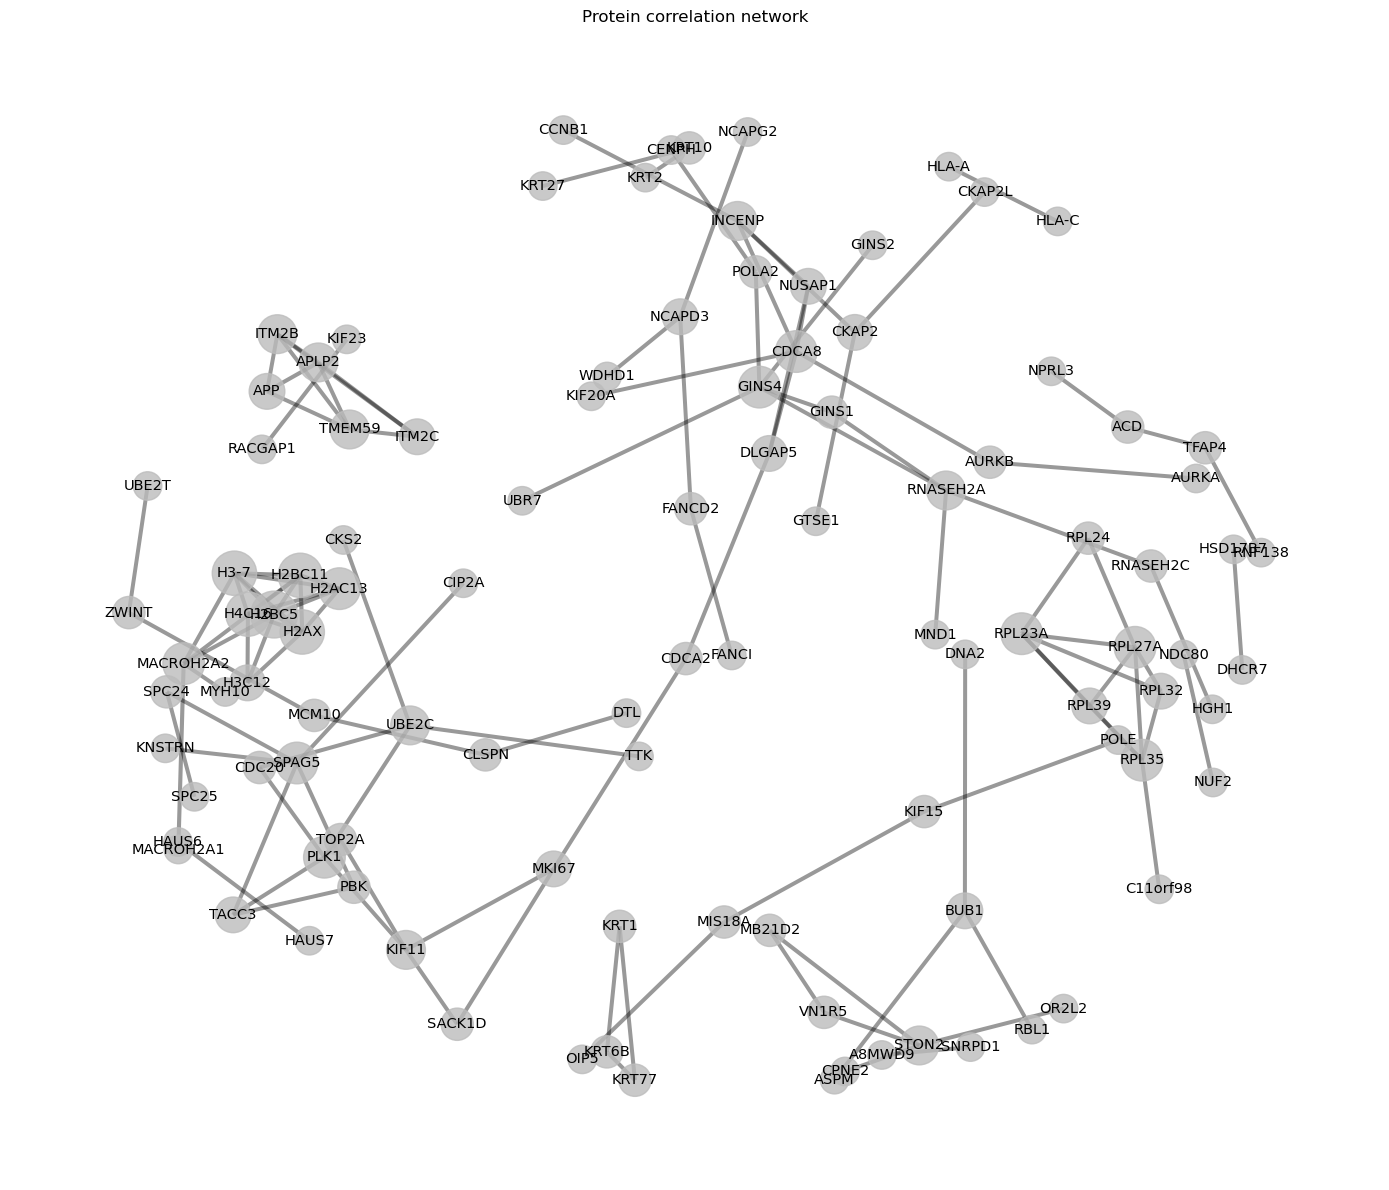

In [78]:
G_top = plot_protein_corr_network(
    edges_df=edges_df_top,   
    gene_symbol_series=gene_symbol_filt,
    node_size_base=300,
    node_size_scale=120,
    edge_width_scale=3,
    font_size=10.5,
    figsize=(14, 12),    
    node_color="#BCBCBC",
    edge_color="black",
    # title="Protein correlation network (top edges)",
    # save_path="protein_corr_network_top_edges.svg"
)

In [144]:
from adjustText import adjust_text
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def plot_protein_corr_network2(
    edges_df,
    gene_symbol_series=None,
    figsize=(12, 12),
    node_size_base=300,
    node_size_scale=100,
    edge_width_scale=3,
    font_size=10,
    node_color="#4C78A8",
    edge_color="gray",
    title="Protein correlation network",
    save_path=None,
    layout_k=0.6,
    label_top_n=None,   # 只标前N个节点，None表示全标
    label_by="degree"   # "degree" or None
):
    if edges_df.empty:
        print("No edges to plot.")
        return None

    G = nx.Graph()

    for _, row in edges_df.iterrows():
        G.add_edge(
            str(row["protein1"]),
            str(row["protein2"]),
            weight=float(row["correlation"])
        )

    nodes_in_graph = list(G.nodes())

    # label map
    if gene_symbol_series is not None:
        gene_symbol_series = gene_symbol_series.copy()
        gene_symbol_series.index = gene_symbol_series.index.astype(str)

        label_map = {}
        for n in nodes_in_graph:
            if n in gene_symbol_series.index:
                g = gene_symbol_series.loc[n]
                if pd.notna(g) and str(g).strip() != "":
                    label_map[n] = str(g)
                else:
                    label_map[n] = str(n)
            else:
                label_map[n] = str(n)
    else:
        label_map = {n: n for n in nodes_in_graph}

    # layout
    pos = nx.spring_layout(G, seed=42, k=layout_k)

    # node size by degree
    degree_dict = dict(G.degree())
    node_sizes = [node_size_base + degree_dict[n] * node_size_scale for n in G.nodes()]

    # edge width by correlation
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [abs(w) * edge_width_scale for w in edge_weights]

    plt.figure(figsize=figsize)
    ax = plt.gca()

    nx.draw_networkx_edges(
        G, pos,
        width=edge_widths,
        alpha=0.6,
        edge_color=edge_color,
        ax=ax
    )

    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        alpha=0.9,
        node_color=node_color,
        ax=ax
    )

    # 选择要标记的节点
    nodes_to_label = list(G.nodes())
    if label_top_n is not None and label_by == "degree":
        nodes_to_label = sorted(G.nodes(), key=lambda n: degree_dict[n], reverse=True)[:label_top_n]

    # 手动画 text，后面用 adjust_text 调整
    texts = []
    for n in nodes_to_label:
        x, y = pos[n]
        txt = ax.text(
            x, y, label_map[n],
            fontsize=font_size,
            color="black",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="none", ec="none", alpha=0.7)
        )
        texts.append(txt)

    # 自动调整标签位置，减少重叠
    adjust_text(
        texts,
        ax=ax,
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
        force_text=(0.5, 0.8),
        force_points=(0.3, 0.5),
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6)
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()
    return G

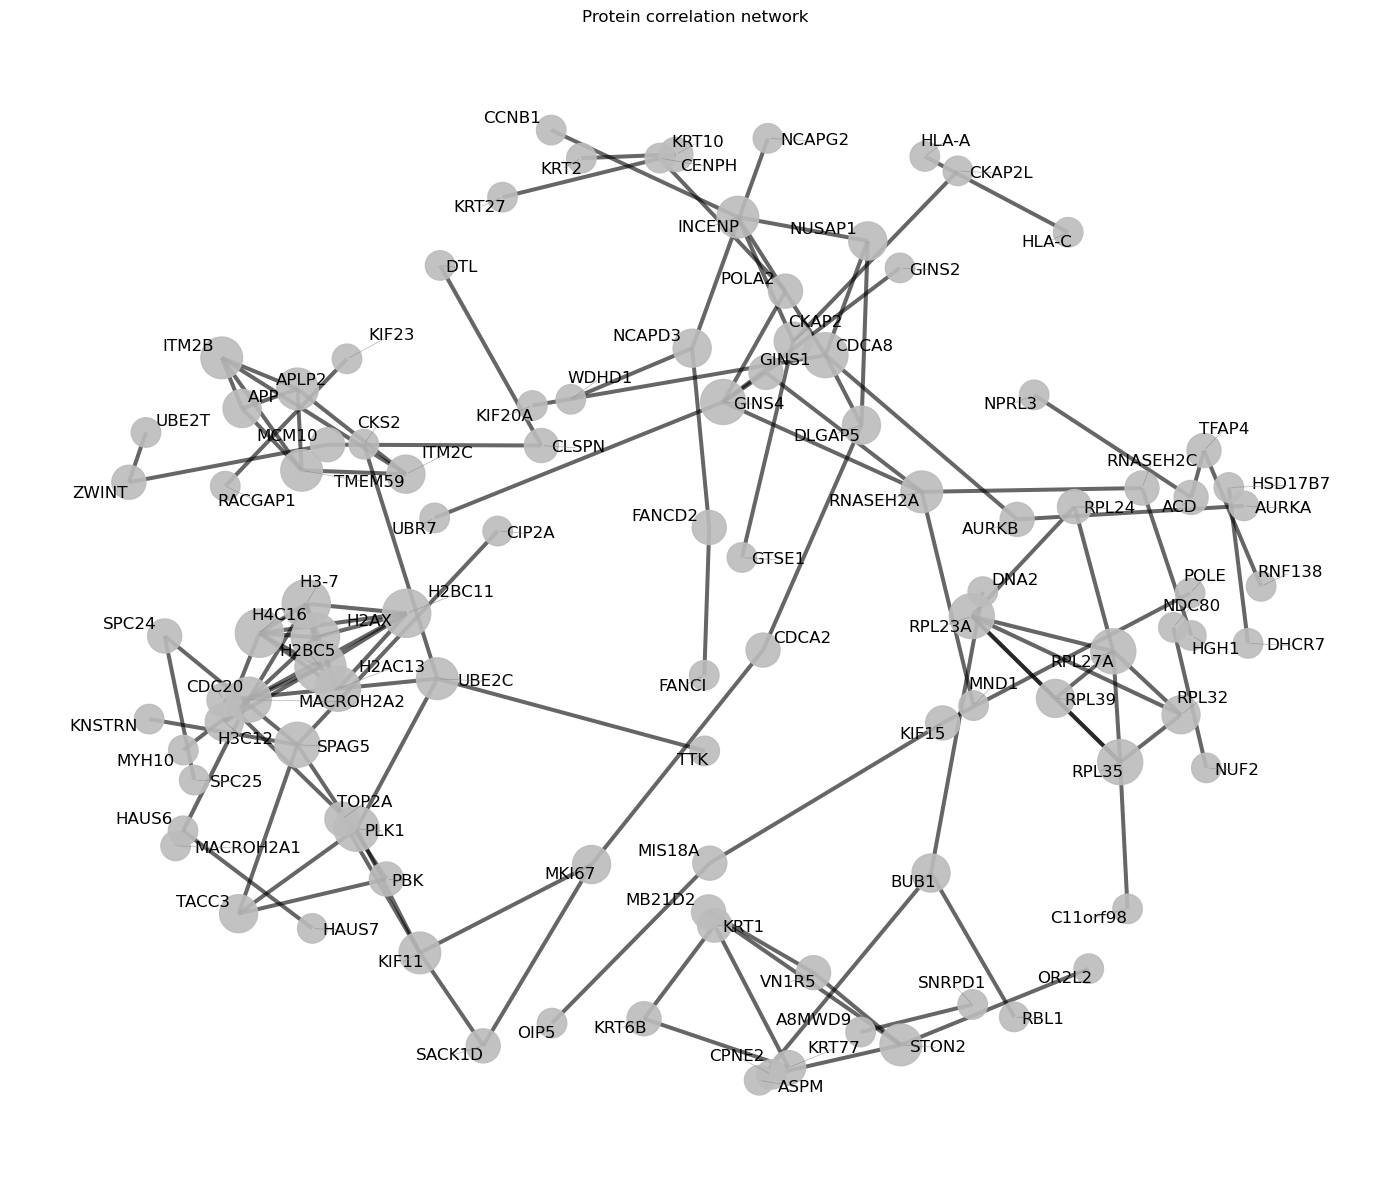

In [145]:

G_top2 = plot_protein_corr_network2(
    edges_df=edges_df_top,   
    gene_symbol_series=gene_symbol_filt,
    node_size_base=300,
    node_size_scale=150,
    edge_width_scale=3,
    font_size=12,
    figsize=(14, 12),    
    node_color="#BCBCBC",
    edge_color="black",
    layout_k=0.4,
    # label_by="degree" 
    # title="Protein correlation network (top edges)",
    save_path=r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\protein_corr_network_top_edges.svg"
)

# plot sub-network

In [146]:
def subset_edges_by_proteins(edges_df, selected_proteins):
    selected_proteins = set(map(str, selected_proteins))

    sub_edges = edges_df[
        edges_df["protein1"].astype(str).isin(selected_proteins) &
        edges_df["protein2"].astype(str).isin(selected_proteins)
    ].copy()

    return sub_edges


def subset_edges_with_neighbors(edges_df, selected_proteins):
    selected_proteins = set(map(str, selected_proteins))

    sub_edges = edges_df[
        edges_df["protein1"].astype(str).isin(selected_proteins) |
        edges_df["protein2"].astype(str).isin(selected_proteins)
    ].copy()

    return sub_edges

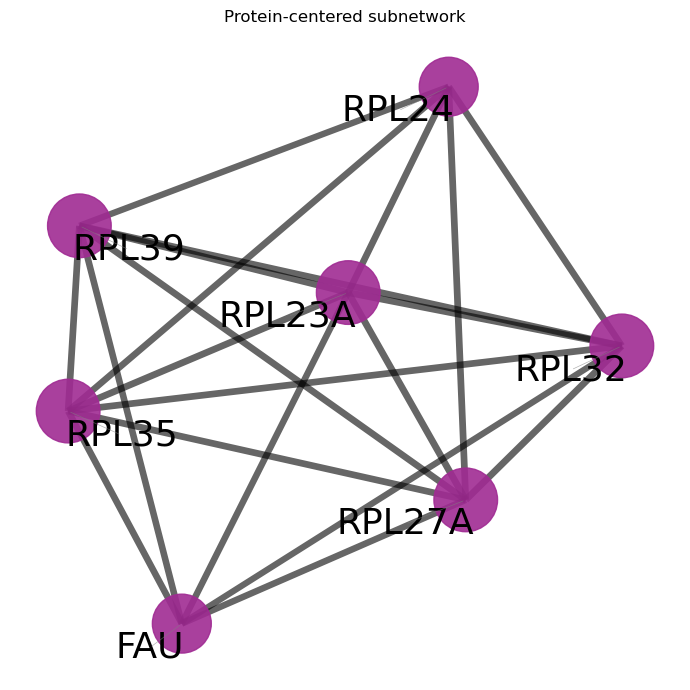

In [171]:
ribosome_cluster = [
    "P62750",
    "P62891",
    "P62861",
    "P62910",
    "P46776",
    "P83731",
    "P42766"
]


sub_edges1 = subset_edges_by_proteins(edges_df, ribosome_cluster)

G_sub1 = plot_protein_corr_network2(
    edges_df=sub_edges1,
    gene_symbol_series=gene_symbol_filt,
    node_size_base=300,
    node_size_scale=300,
    edge_width_scale=5,
    font_size=26,
    figsize=(7, 7),
    node_color="#A02B93",
    edge_color="black",
    layout_k=1.4,
    title="Protein-centered subnetwork",
    save_path=r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures\proteinClustering\protein_corr_sub_network_ribosome_cluster.svg"
)

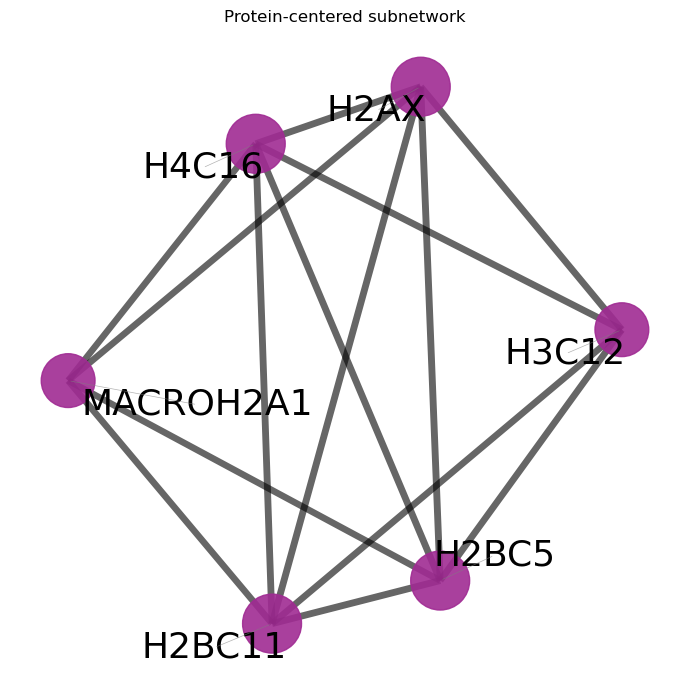

In [170]:
histone_cluster = [
    "P68431",
    "P62805",
    "P16104",
    "P58876",
    "P06899",
    "O75367"
]


sub_edges1 = subset_edges_by_proteins(edges_df, histone_cluster)

G_sub1 = plot_protein_corr_network2(
    edges_df=sub_edges1,
    gene_symbol_series=gene_symbol_filt,
    node_size_base=300,
    node_size_scale=300,
    edge_width_scale=5,
    font_size=26,
    figsize=(7, 7),
    node_color="#A02B93",
    edge_color="black",
    layout_k=1.4,
    title="Protein-centered subnetwork",
    save_path=r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures\proteinClustering\protein_corr_sub_network_histone_cluster.svg"
)

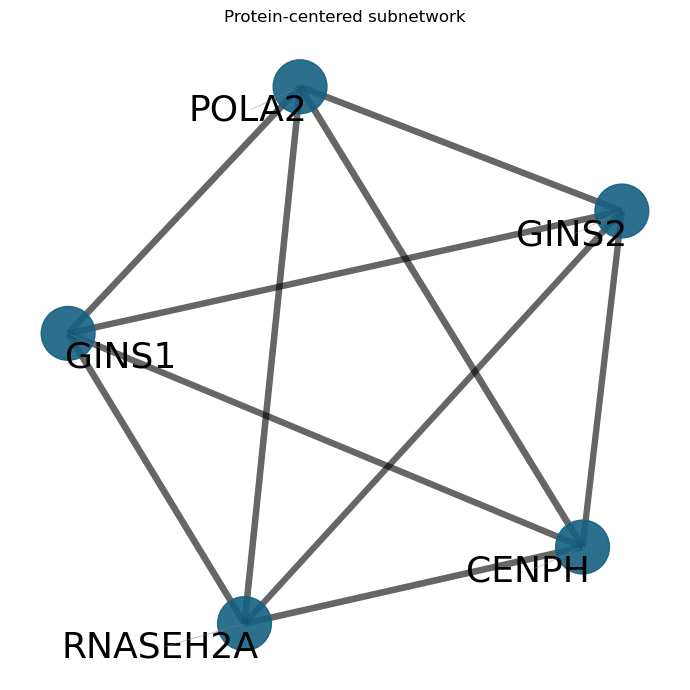

In [169]:
novel_cluster1 = [
    "O75792",
    "Q14181",
    "Q14691",
    "Q9H3R5",
    "Q9Y248"
]

sub_edges2 = subset_edges_by_proteins(edges_df, novel_cluster1)

G_sub2 = plot_protein_corr_network2(
    edges_df=sub_edges2,
    gene_symbol_series=gene_symbol_filt,
    node_size_base=300,
    node_size_scale=300,
    edge_width_scale=5,
    font_size=26,
    figsize=(7, 7),
    node_color="#156082",
    edge_color="black",
    layout_k=1.4,
    title="Protein-centered subnetwork",
    save_path=r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures\proteinClustering\protein_corr_sub_network_novel_cluster1.svg"
)




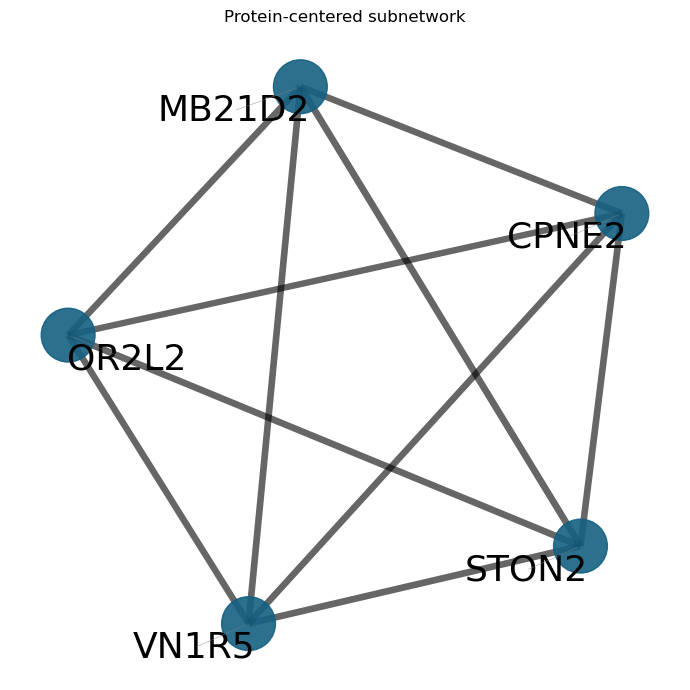

In [168]:
novel_cluster2 = [
    "Q7Z5H4",
    "Q8IYB1",
    "Q8NH16",
    "Q96FN4",
    "Q8WXE9"
]


sub_edges2 = subset_edges_by_proteins(edges_df, novel_cluster2)

G_sub2 = plot_protein_corr_network2(
    edges_df=sub_edges2,
    gene_symbol_series=gene_symbol_filt,
    node_size_base=300,
    node_size_scale=300,
    edge_width_scale=5,
    font_size=26,
    figsize=(7, 7),
    node_color="#156082",
    edge_color="black",
    layout_k=1.4,
    title="Protein-centered subnetwork",
    save_path=r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures\proteinClustering\protein_corr_sub_network_novel_cluster2.svg"
)
